In [ ]:
%%capture
!pip install opendatasets

In [ ]:
import opendatasets as od
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [ ]:
dataset_url = 'https://www.kaggle.com/datasets/vicsuperman/prediction-of-music-genre'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: tayasmells
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vicsuperman/prediction-of-music-genre


100%|██████████| 2.72M/2.72M [00:00<00:00, 588MB/s]

In [ ]:
df = pd.read_csv('./prediction-of-music-genre/music_genre.csv')

display(df.head())
print(df.shape)

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


(50005, 18)


In [ ]:
df_processed = df.copy()

cols_to_drop = ['instance_id', 'artist_name', 'track_name', 'obtained_date']
df_processed = df_processed.drop(columns=cols_to_drop)

In [ ]:
TONALITIES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
tonality_to_number = {tonality: idx for idx, tonality in enumerate(TONALITIES)}
df_processed['key_encoded'] = df_processed['key'].map(tonality_to_number)
df_processed = df_processed.drop(columns=['key'])

In [ ]:
df_processed['mode_encoded'] = df_processed['mode'].map({'Major': 1, 'Minor': 0})
df_processed = df_processed.drop(columns=['mode'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_processed['music_genre_encoded'] = le.fit_transform(df_processed['music_genre']) # все уникальные жанры закодировали в числа


genre_classes = le.classes_
df_processed = df_processed.drop(columns=['music_genre'])

In [ ]:
display(df_processed.head())
print(df_processed.shape)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_encoded,mode_encoded,music_genre_encoded
0,27.0,0.00468,0.652,-1.0,0.941,0.79200,0.115,-5.201,0.0748,100.889,0.759,10.0,0.0,5
1,31.0,0.01270,0.622,218293.0,0.890,0.95000,0.124,-7.043,0.0300,115.00200000000001,0.531,2.0,0.0,5
2,28.0,0.00306,0.620,215613.0,0.755,0.01180,0.534,-4.617,0.0345,127.994,0.333,8.0,1.0,5
3,34.0,0.02540,0.774,166875.0,0.700,0.00253,0.157,-4.498,0.2390,128.014,0.270,1.0,1.0,5
4,32.0,0.00465,0.638,222369.0,0.587,0.90900,0.157,-6.266,0.0413,145.036,0.323,6.0,1.0,5


(50005, 14)


In [ ]:
import numpy as np
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df_processed[col].dtype == 'object':
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')


df_processed = df_processed.replace('?', np.nan)

In [ ]:
correlation = df_processed.corr()['music_genre_encoded'].abs().sort_values(ascending=False)

correlation = correlation.drop('music_genre_encoded')
print(correlation)

top_10_features = correlation.head(10).index
df_processed = df_processed[list(top_10_features) + ['music_genre_encoded']]

popularity          0.502133
danceability        0.303463
speechiness         0.190536
instrumentalness    0.110432
loudness            0.102520
acousticness        0.097969
valence             0.075065
mode_encoded        0.039832
energy              0.034738
duration_ms         0.028517
liveness            0.025227
tempo               0.022762
key_encoded         0.005047
Name: music_genre_encoded, dtype: float64


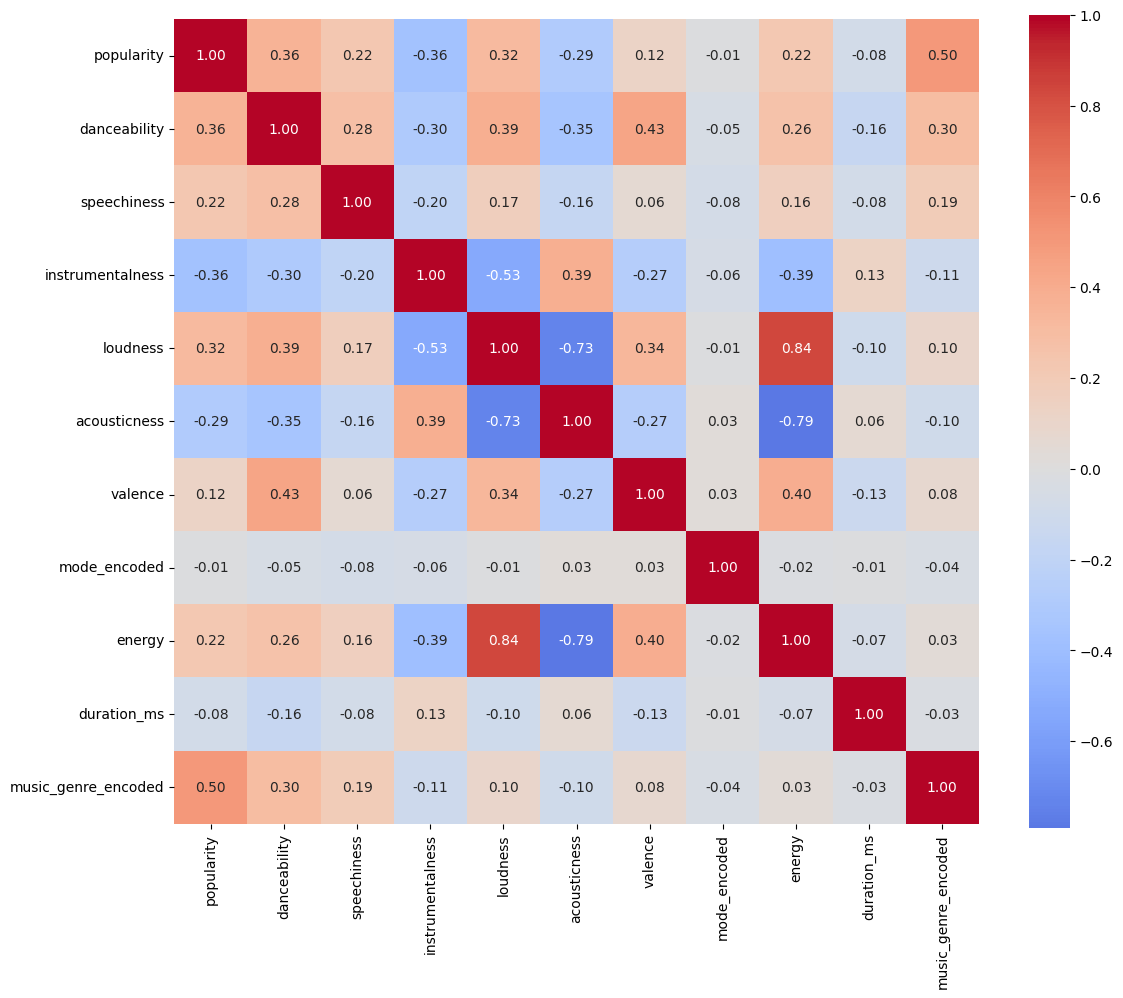

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
corr_matrix = df_processed.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True)
plt.tight_layout()
plt.show()

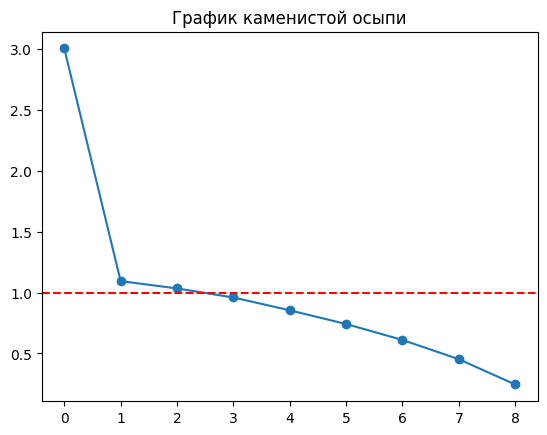

In [ ]:
eigenvalues = np.linalg.eigvals(df_processed.drop(columns=['music_genre_encoded', 'energy']).corr())
plt.plot(np.sort(eigenvalues)[::-1], 'o-')
plt.axhline(y=1, color='red', linestyle='--')
plt.title('График каменистой осыпи')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np

X = df_processed.drop(columns=['music_genre_encoded', 'energy'])

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print("Объясненная дисперсия для каждой компоненты:")
for i, variance in enumerate(pca.explained_variance_ratio_, 1):
    print(f"Компонента {i}: {variance:.4f} ({variance*100:.2f}%)")

Объясненная дисперсия для каждой компоненты:
Компонента 1: 0.3338 (33.38%)
Компонента 2: 0.1216 (12.16%)
Компонента 3: 0.1149 (11.49%)


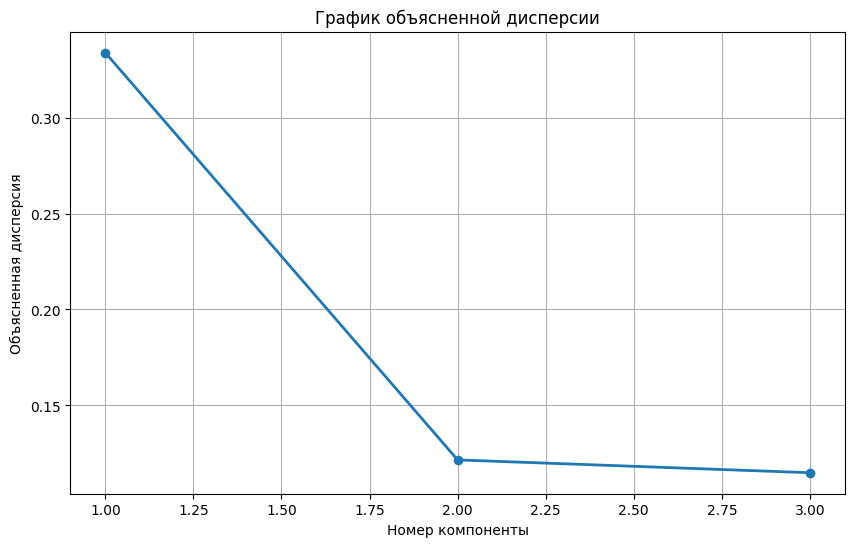

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, 'o-', linewidth=2)
plt.xlabel('Номер компоненты')
plt.ylabel('Объясненная дисперсия')
plt.title('График объясненной дисперсии')
plt.grid(True)
plt.show()

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"\nНакопленная объясненная дисперсия:")
print(f"Первая компонента: {cumulative_variance[0]:.4f} ({cumulative_variance[0]*100:.2f}%)")
print(f"Первые две компоненты: {cumulative_variance[1]:.4f} ({cumulative_variance[1]*100:.2f}%)")
print(f"Все три компоненты: {cumulative_variance[2]:.4f} ({cumulative_variance[2]*100:.2f}%)")


Накопленная объясненная дисперсия:
Первая компонента: 0.3338 (33.38%)
Первые две компоненты: 0.4554 (45.54%)
Все три компоненты: 0.5704 (57.04%)


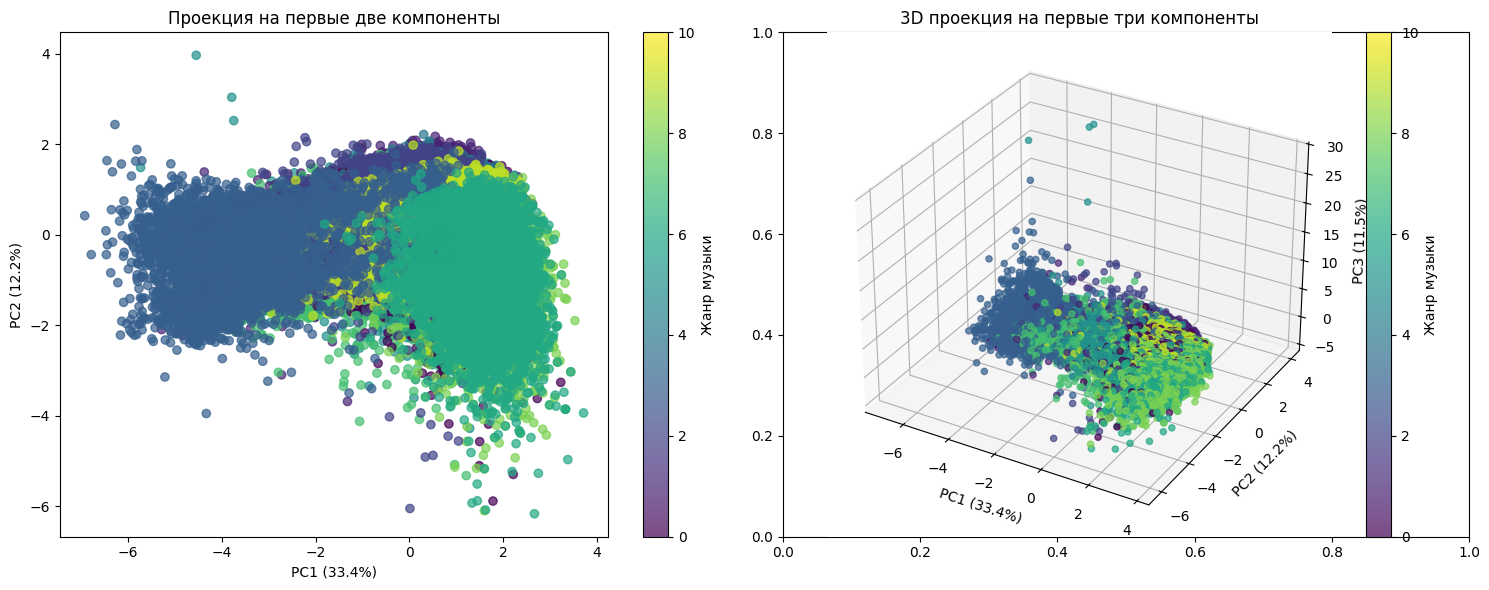

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['music_genre'] = df_processed['music_genre_encoded'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

scatter = ax1.scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['music_genre'], cmap='viridis', alpha=0.7)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('Проекция на первые две компоненты')
plt.colorbar(scatter, ax=ax1, label='Жанр музыки')

ax2 = fig.add_subplot(122, projection='3d')
scatter_3d = ax2.scatter(pca_df['PC1'], pca_df['PC2'], pca_df['PC3'],
                        c=pca_df['music_genre'], cmap='viridis', alpha=0.7)
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)')
ax2.set_title('3D проекция на первые три компоненты')
plt.colorbar(scatter_3d, ax=ax2, label='Жанр музыки')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

KeyboardInterrupt: 

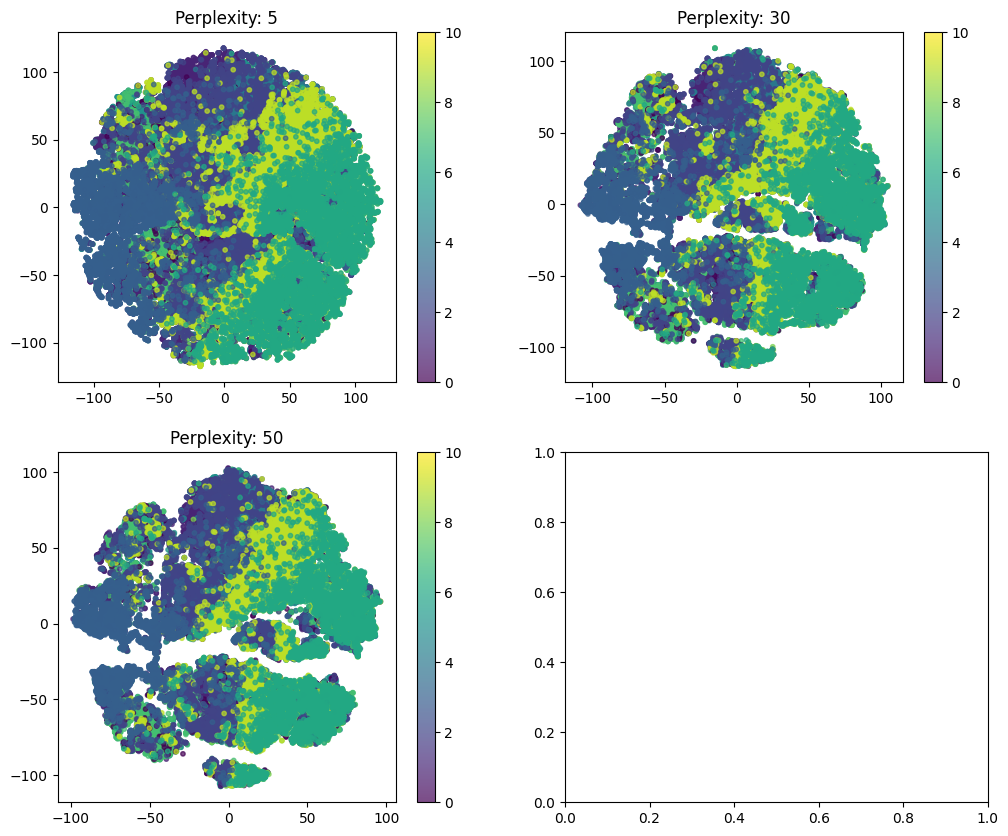

In [ ]:
X = df_processed.drop(columns=['music_genre_encoded', 'energy'])

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
y = df_processed['music_genre_encoded']

perplexities = [5, 30, 50, 100]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, perplexity in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    scatter = axes[i//2, i%2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='viridis', alpha=0.7, s=10)
    axes[i//2, i%2].set_title(f'Perplexity: {perplexity}')
    plt.colorbar(scatter, ax=axes[i//2, i%2])

plt.tight_layout()
plt.show()